DECISION TREE CLASSIFIER - PROFESSIONAL ANALYSIS
Save directory : /kaggle/working/dt_models/

BLOCK 1: LOADING DATASET
  Loaded in      : 2.1s
  Total samples  : 178,930
  Features       : 44
  Violation rate : 5.13%
  Normal         : 169,752
  Violated       : 9,178

BLOCK 2: TEMPORAL SPLIT
  Train : 135,986 | Violations: 6916 (5.09%)
  Val   : 33,997 | Violations: 1762 (5.18%)
  Test  : 8,947 | Violations: 500 (5.59%)

BLOCK 3: FEATURE SCALING
  Post-scale mean : -0.000000
  Post-scale std  : 1.000000
  Scaler saved for inference

BLOCK 4: STRATIFIED UNDERSAMPLING
  Before : Normal=129,070 | Violated=6,916
  After  : Normal=20,748 | Violated=6,916
  Ratio  : 3 : 1

BLOCK 5: HYPERPARAMETER SEARCH
  Best Params:
    min_samples_split : 5
    min_samples_leaf  : 1
    max_depth         : 5
    criterion         : entropy

BLOCK 7: TRAINING BEST MODEL
  Initializing Decision Tree model with best hyperparameters...
  Training dataset size : 27,664
  Feature count         : 44
  Class dis

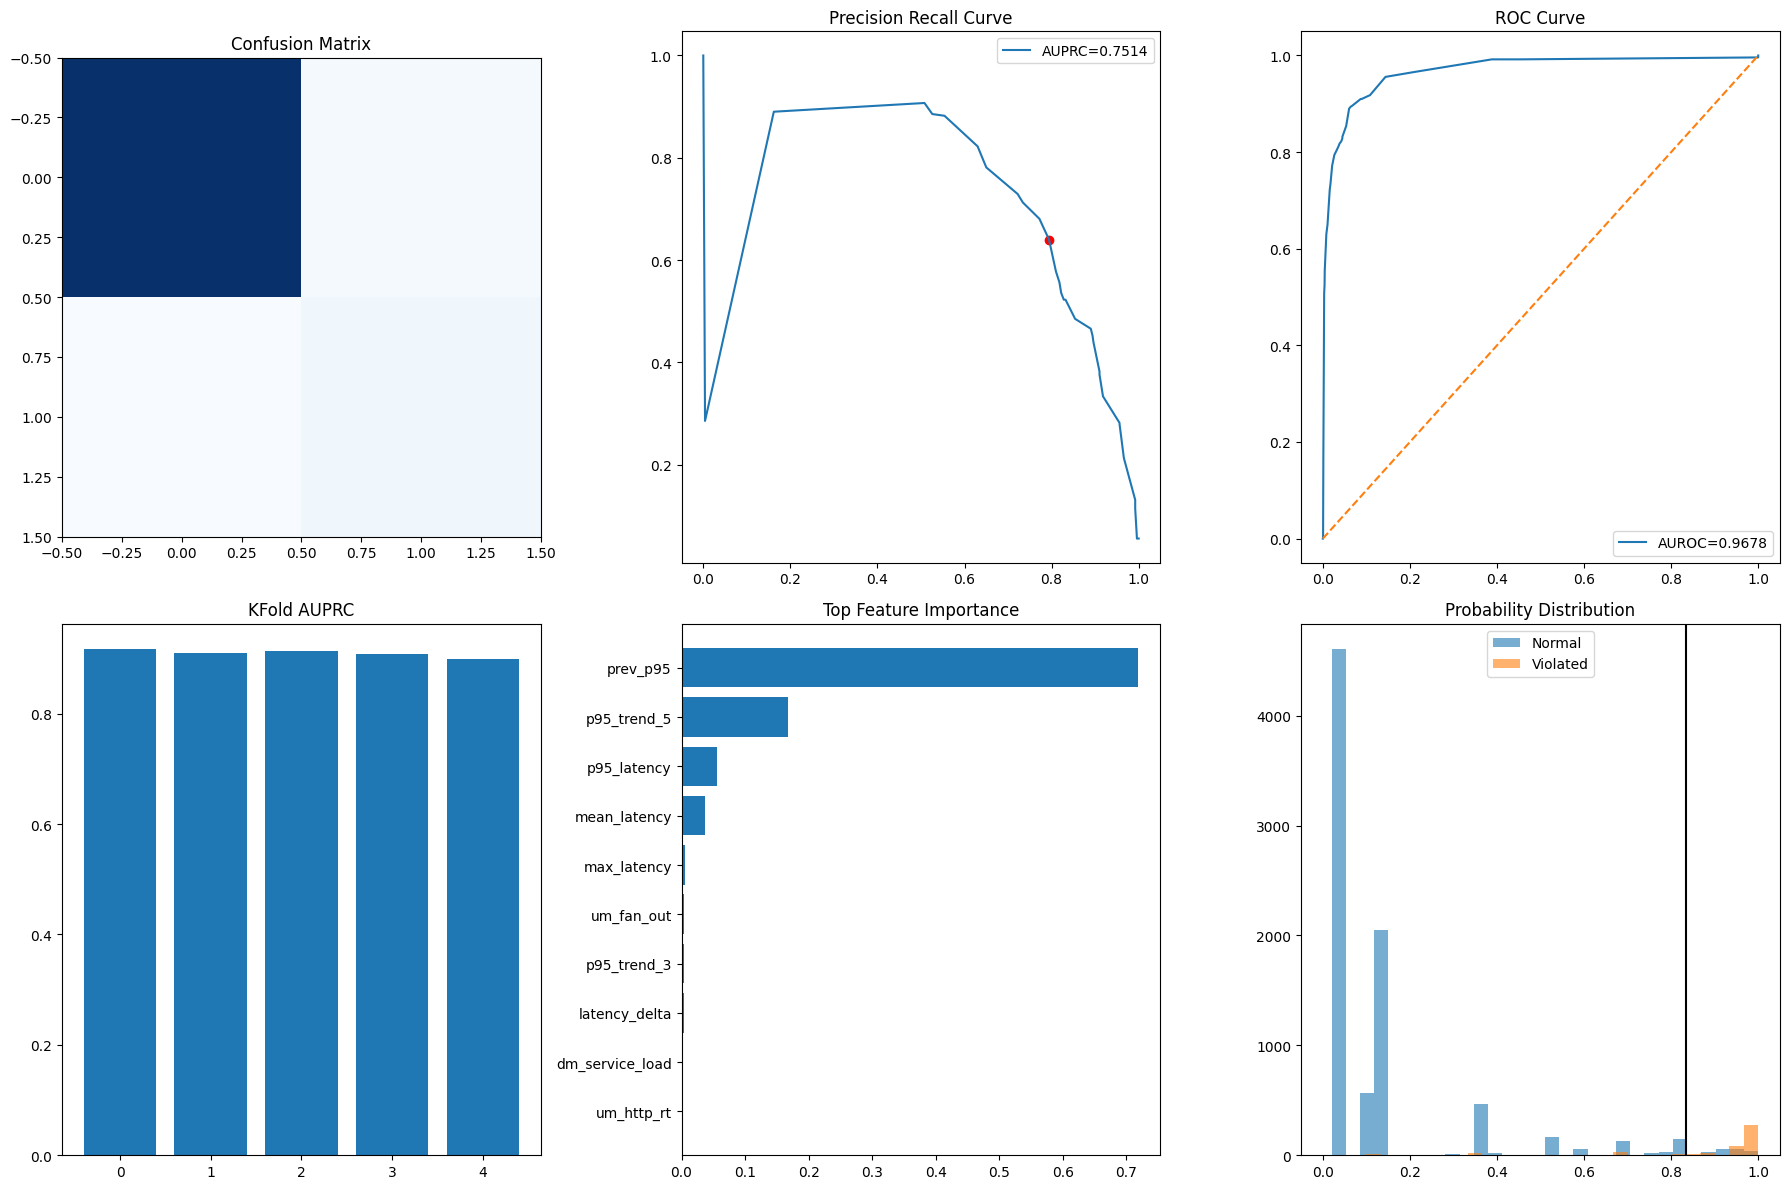


BLOCK 13: FINAL SUMMARY
Test AUPRC         : 0.7514
Test AUROC         : 0.9678
Test F1 (optimal)  : 0.7089
Test F2 (optimal)  : 0.7576
Accuracy           : 0.9636
KFold AUPRC        : 0.9092 ± 0.0062
Optimal threshold  : 0.8333


In [1]:
import os
import json
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_curve
)
import joblib

warnings.filterwarnings("ignore")

# =============================================================
# CONFIGURATION
# =============================================================
FILE_PATH = "/kaggle/input/datasets/harshavardhan0307/ml-project/Final_Topology_Dataset_FULL_0_to_5__2.csv"
SAVE_DIR = "/kaggle/working/dt_models/"
os.makedirs(SAVE_DIR, exist_ok=True)

print("=" * 60)
print("DECISION TREE CLASSIFIER - PROFESSIONAL ANALYSIS")
print("=" * 60)
print(f"Save directory : {SAVE_DIR}")
print("=" * 60)


# =============================================================
# BLOCK 1: LOAD DATASET
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 1: LOADING DATASET")
print("=" * 60)

t0 = time.time()

df = pd.read_csv(FILE_PATH)
df = df.sort_values("time_window").reset_index(drop=True)

NON_FEATURE_COLS = ['um', 'dm', 'time_window', 'violation_next_window']
FEATURE_COLS = [c for c in df.columns if c not in NON_FEATURE_COLS]
TARGET = 'violation_next_window'

X = df[FEATURE_COLS].fillna(-1).values
y = df[TARGET].values

print(f"  Loaded in      : {time.time()-t0:.1f}s")
print(f"  Total samples  : {len(df):,}")
print(f"  Features       : {len(FEATURE_COLS)}")
print(f"  Violation rate : {y.mean()*100:.2f}%")
print(f"  Normal         : {(y==0).sum():,}")
print(f"  Violated       : {(y==1).sum():,}")


# =============================================================
# BLOCK 2: TEMPORAL SPLIT
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 2: TEMPORAL SPLIT")
print("=" * 60)

n = len(df)
test_start = int(n * 0.95)
val_start = int(test_start * 0.80)

X_train_raw = X[:val_start]
y_train_raw = y[:val_start]
X_val_raw = X[val_start:test_start]
y_val_raw = y[val_start:test_start]
X_test_raw = X[test_start:]
y_test_raw = y[test_start:]

print(f"  Train : {len(X_train_raw):,} | Violations: {y_train_raw.sum():.0f} ({y_train_raw.mean()*100:.2f}%)")
print(f"  Val   : {len(X_val_raw):,} | Violations: {y_val_raw.sum():.0f} ({y_val_raw.mean()*100:.2f}%)")
print(f"  Test  : {len(X_test_raw):,} | Violations: {y_test_raw.sum():.0f} ({y_test_raw.mean()*100:.2f}%)")


# =============================================================
# BLOCK 3: FEATURE SCALING
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 3: FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"  Post-scale mean : {X_train_scaled.mean():.6f}")
print(f"  Post-scale std  : {X_train_scaled.std():.6f}")
print("  Scaler saved for inference")


# =============================================================
# BLOCK 4: STRATIFIED UNDERSAMPLING
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 4: STRATIFIED UNDERSAMPLING")
print("=" * 60)

minority_idx = np.where(y_train_raw == 1)[0]
majority_idx = np.where(y_train_raw == 0)[0]

RATIO = 3
n_majority = min(len(minority_idx) * RATIO, len(majority_idx))
sampled_majority = np.random.default_rng(42).choice(majority_idx, n_majority, replace=False)

train_idx = np.concatenate([minority_idx, sampled_majority])
np.random.default_rng(42).shuffle(train_idx)

X_train_bal = X_train_scaled[train_idx]
y_train_bal = y_train_raw[train_idx]

neg = (y_train_bal == 0).sum()
pos = (y_train_bal == 1).sum()

print(f"  Before : Normal={len(majority_idx):,} | Violated={len(minority_idx):,}")
print(f"  After  : Normal={int(neg):,} | Violated={int(pos):,}")
print(f"  Ratio  : {int(neg/pos)} : 1")


# =============================================================
# BLOCK 5: HYPERPARAMETER SEARCH
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 5: HYPERPARAMETER SEARCH")
print("=" * 60)

param_grid = {
    "max_depth": [5,10,15,20,25,30,None],
    "min_samples_split":[2,5,10,20],
    "min_samples_leaf":[1,2,4,8],
    "criterion":["gini","entropy"]
}

base_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)

search = RandomizedSearchCV(
    base_model,
    param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_bal, y_train_bal)

best_params = search.best_params_

print("  Best Params:")
for k,v in best_params.items():
    print(f"    {k:<18}: {v}")


# =============================================================
# BLOCK 7: TRAINING BEST MODEL
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 7: TRAINING BEST MODEL")
print("=" * 60)

print("  Initializing Decision Tree model with best hyperparameters...")
print(f"  Training dataset size : {len(X_train_bal):,}")
print(f"  Feature count         : {len(FEATURE_COLS)}")
print("  Class distribution:")
print(f"    Normal   : {(y_train_bal == 0).sum():,}")
print(f"    Violated : {(y_train_bal == 1).sum():,}")

best_model = DecisionTreeClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42
)

print("\n  Starting model training...")

t0 = time.time()

best_model.fit(X_train_bal, y_train_bal)

elapsed = time.time() - t0

print("  Training completed.")
print(f"  Training time        : {elapsed:.4f} seconds")
print(f"  Tree depth           : {best_model.tree_.max_depth}")
print(f"  Number of nodes      : {best_model.tree_.node_count}")
print(f"  Number of leaves     : {best_model.get_n_leaves()}")

# -------- ROOT NODE FEATURE --------
root_feature_index = best_model.tree_.feature[0]

if root_feature_index != -2:
    root_feature_name = FEATURE_COLS[root_feature_index]
else:
    root_feature_name = "Leaf Node"

print(f"  Root node feature    : {root_feature_name}")
print(f"  Features used        : {len(FEATURE_COLS)}")

joblib.dump(best_model, SAVE_DIR + "dt_best_model.pkl")
joblib.dump(scaler, SAVE_DIR + "scaler.pkl")

print("  dt_best_model.pkl : Saved")
print("  scaler.pkl        : Saved")


# =============================================================
# BLOCK 8: K-FOLD CROSS VALIDATION (K=5)
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 8: K-FOLD CROSS VALIDATION (K=5)")
print("=" * 60)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_auprcs = []
fold_aurocs = []
fold_f1_scores = []
fold_f2_scores = []

for fold_num, (tr_idx, vl_idx) in enumerate(kf.split(X_train_bal, y_train_bal)):
    
    print(f"\n  Fold {fold_num+1}/5")

    fold_model = DecisionTreeClassifier(
        **best_params,
        class_weight="balanced",
        random_state=42
    )

    fold_model.fit(X_train_bal[tr_idx], y_train_bal[tr_idx])

    probs = fold_model.predict_proba(X_train_bal[vl_idx])[:,1]

    auprc = average_precision_score(y_train_bal[vl_idx], probs)
    auroc = roc_auc_score(y_train_bal[vl_idx], probs)

    preds = (probs >= 0.5).astype(int)

    f1 = f1_score(y_train_bal[vl_idx], preds)
    f2 = fbeta_score(y_train_bal[vl_idx], preds, beta=2)

    fold_auprcs.append(auprc)
    fold_aurocs.append(auroc)
    fold_f1_scores.append(f1)
    fold_f2_scores.append(f2)

    print(f"  Fold {fold_num+1}/5 | AUPRC: {auprc:.4f} | AUROC: {auroc:.4f} | F1: {f1:.4f} | F2: {f2:.4f}")

print("\n  K-Fold Results")
print(f"    Mean AUPRC : {np.mean(fold_auprcs):.4f} ± {np.std(fold_auprcs):.4f}")
print(f"    Mean AUROC : {np.mean(fold_aurocs):.4f} ± {np.std(fold_aurocs):.4f}")

# =============================================================
# BLOCK 9: THRESHOLD OPTIMIZATION
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 9: THRESHOLD OPTIMIZATION")
print("=" * 60)

val_probs = best_model.predict_proba(X_val_scaled)[:,1]

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_val_raw, val_probs
)

f2_scores = []
f1_scores = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)

    f2_scores.append(
        fbeta_score(y_val_raw, preds, beta=2, zero_division=0)
    )

    f1_scores.append(
        f1_score(y_val_raw, preds, zero_division=0)
    )

f2_scores = np.array(f2_scores)
f1_scores = np.array(f1_scores)

best_thresh = thresholds[np.argmax(f2_scores)]
best_f1_thresh = thresholds[np.argmax(f1_scores)]

print(f"  Optimal threshold (F2) : {best_thresh:.4f}")
print(f"  Optimal threshold (F1) : {best_f1_thresh:.4f}")

# =============================================================
# BLOCK 10: FINAL TEST SET EVALUATION
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 10: FINAL TEST SET EVALUATION")
print("=" * 60)

test_probs = best_model.predict_proba(X_test_scaled)[:,1]

test_preds_05 = (test_probs >= 0.5).astype(int)
test_preds_opt = (test_probs >= best_thresh).astype(int)

test_auprc = average_precision_score(y_test_raw, test_probs)
test_auroc = roc_auc_score(y_test_raw, test_probs)

prec_05 = precision_score(y_test_raw, test_preds_05)
rec_05 = recall_score(y_test_raw, test_preds_05)
f1_05 = f1_score(y_test_raw, test_preds_05)
f2_05 = fbeta_score(y_test_raw, test_preds_05, beta=2)

prec_opt = precision_score(y_test_raw, test_preds_opt)
rec_opt = recall_score(y_test_raw, test_preds_opt)
f1_opt = f1_score(y_test_raw, test_preds_opt)
f2_opt = fbeta_score(y_test_raw, test_preds_opt, beta=2)

acc_opt = (test_preds_opt == y_test_raw).mean()

print("\n  FINAL TEST METRICS")
print("  ----------------------------------------------------------")
print(f"  {'Metric':<20}{'Threshold=0.50':>16}{f'Optimal ({best_thresh:.3f})':>18}")
print("  ----------------------------------------------------------")
print(f"  {'AUPRC':<20}{'N/A':>16}{test_auprc:>18.4f}")
print(f"  {'AUROC':<20}{'N/A':>16}{test_auroc:>18.4f}")
print(f"  {'Precision':<20}{prec_05:>16.4f}{prec_opt:>18.4f}")
print(f"  {'Recall':<20}{rec_05:>16.4f}{rec_opt:>18.4f}")
print(f"  {'F1 Score':<20}{f1_05:>16.4f}{f1_opt:>18.4f}")
print(f"  {'F2 Score':<20}{f2_05:>16.4f}{f2_opt:>18.4f}")
print(f"  {'Accuracy':<20}{'N/A':>16}{acc_opt:>18.4f}")

print("\n" + "-"*50)
print("PERFORMANCE METRICS")
print("-"*50)

print(f"AUPRC       : {test_auprc:.4f}")
print(f"AUROC       : {test_auroc:.4f}")
print(f"Accuracy    : {acc_opt:.4f}")
print(f"Precision   : {prec_opt:.4f}")
print(f"Recall      : {rec_opt:.4f}")
print(f"F1 Score    : {f1_opt:.4f}")
print(f"F2 Score    : {f2_opt:.4f}")

print("\nClassification Report")
print(classification_report(
    y_test_raw,
    test_preds_opt,
    target_names=["Normal","Violated"]
))
# =============================================================
# BLOCK 11: FEATURE IMPORTANCE
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 11: FEATURE IMPORTANCE")
print("=" * 60)

importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 10 Features")
for i,row in feature_importance_df.head(10).iterrows():
    print(f"  {row['feature']:<30}{row['importance']:.4f}")

# =============================================================
# BLOCK 12: GENERATING PLOTS
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 12: GENERATING PLOTS")
print("=" * 60)

fpr,tpr,_ = roc_curve(y_test_raw,test_probs)

fig = plt.figure(figsize=(18,12))
gs = gridspec.GridSpec(2,3)

# Confusion matrix
ax1 = fig.add_subplot(gs[0,0])
cm = confusion_matrix(y_test_raw,test_preds_opt)
ax1.imshow(cm,cmap="Blues")
ax1.set_title("Confusion Matrix")

# PR curve
ax2 = fig.add_subplot(gs[0,1])
prec,rec,_ = precision_recall_curve(y_test_raw,test_probs)
ax2.plot(rec,prec,label=f"AUPRC={test_auprc:.4f}")
ax2.scatter(rec_opt,prec_opt,color="red")
ax2.set_title("Precision Recall Curve")
ax2.legend()

# ROC curve
ax3 = fig.add_subplot(gs[0,2])
ax3.plot(fpr,tpr,label=f"AUROC={test_auroc:.4f}")
ax3.plot([0,1],[0,1],'--')
ax3.set_title("ROC Curve")
ax3.legend()

# Kfold
ax4 = fig.add_subplot(gs[1,0])
ax4.bar(range(5),fold_auprcs)
ax4.set_title("KFold AUPRC")

# Feature importance
ax5 = fig.add_subplot(gs[1,1])
idx = np.argsort(importances)[-10:]
ax5.barh(np.array(FEATURE_COLS)[idx],importances[idx])
ax5.set_title("Top Feature Importance")

# Probability distribution
ax6 = fig.add_subplot(gs[1,2])
ax6.hist(test_probs[y_test_raw==0],bins=30,alpha=0.6,label="Normal")
ax6.hist(test_probs[y_test_raw==1],bins=30,alpha=0.6,label="Violated")
ax6.axvline(best_thresh,color="black")
ax6.set_title("Probability Distribution")
ax6.legend()

plt.tight_layout()
plt.savefig(SAVE_DIR+"dt_full_analysis.png",dpi=150)
plt.show()

# =============================================================
# BLOCK 13: FINAL SUMMARY
# =============================================================
print("\n" + "=" * 60)
print("BLOCK 13: FINAL SUMMARY")
print("=" * 60)

print(f"Test AUPRC         : {test_auprc:.4f}")
print(f"Test AUROC         : {test_auroc:.4f}")
print(f"Test F1 (optimal)  : {f1_opt:.4f}")
print(f"Test F2 (optimal)  : {f2_opt:.4f}")
print(f"Accuracy           : {acc_opt:.4f}")
print(f"KFold AUPRC        : {np.mean(fold_auprcs):.4f} ± {np.std(fold_auprcs):.4f}")
print(f"Optimal threshold  : {best_thresh:.4f}")